### Imports

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 1) Chargement de la base de données

In [61]:
import pandas as pd
df = pd.read_csv('./data/candidats.csv')
df.shape


(20000, 12)

In [62]:
df.columns

Index(['Unnamed: 0', 'date', 'cheveux', 'age', 'exp', 'salaire', 'sexe',
       'diplome', 'specialite', 'note', 'dispo', 'embauche'],
      dtype='object')

In [63]:
display(df.head())

,Unnamed: 0,date,cheveux,age,exp,salaire,sexe,diplome,specialite,note,dispo,embauche
0,0,2012-06-02,roux,25.0,9.0,26803.0,F,licence,geologie,97.08,non,0
1,1,2011-04-21,blond,35.0,13.0,38166.0,M,licence,forage,63.86,non,0
2,2,2012-09-07,blond,29.0,13.0,35207.0,M,licence,geologie,78.50,non,0
3,3,2011-07-01,brun,NaN,12.0,32442.0,M,licence,geologie,45.09,non,0
4,4,2012-08-07,roux,35.0,6.0,28533.0,F,licence,detective,81.91,non,0


In [64]:
print('\nTypes:')
print(df.dtypes)


Types:
Unnamed: 0      int64
date           object
cheveux        object
age           float64
exp           float64
salaire       float64
sexe           object
diplome        object
specialite     object
note          float64
dispo          object
embauche        int64
dtype: object


## Objectifs de l'analyse

# 1-Analyse des facteurs liés à l'embauche

In [65]:
print(" STATISTIQUES GÉNÉRALES")
print(f"Nombre total de candidats: {len(df)}")
print(f"Nombre d'embauchés: {df['embauche'].sum()}")
print(f"Taux d'embauche: {df['embauche'].mean()*100:.1f}%")

 STATISTIQUES GÉNÉRALES
Nombre total de candidats: 20000
Nombre d'embauchés: 2292
Taux d'embauche: 11.5%


In [118]:
print("STATISTIQUES PAR GROUPE:")
stats_desc = df.groupby('embauche')[['age', 'exp', 'salaire', 'note']].agg(['mean', 'median', 'std', 'min', 'max'])
print(stats_desc.round(2))

STATISTIQUES PAR GROUPE:
            age                           exp                          \
           mean median   std  min   max  mean median   std  min   max   
embauche                                                                
0         35.04   35.0  9.59 -3.0  72.0  9.49    9.0  3.02 -2.0  23.0   
1         34.69   35.0  9.74  1.0  74.0  9.56   10.0  2.96  0.0  20.0   

           salaire                                       note                \
              mean   median      std      min      max   mean median    std   
embauche                                                                      
0         34970.12  34976.0  5050.70  14128.0  53977.0  75.15  75.07  17.23   
1         35006.88  34996.0  4620.51  17047.0  51093.0  75.31  75.11  15.99   

                         
            min     max  
embauche                 
0          8.68  134.45  
1         21.26  143.22  


### DISTRIBUTIONS D'EMBAUCHE par Densité

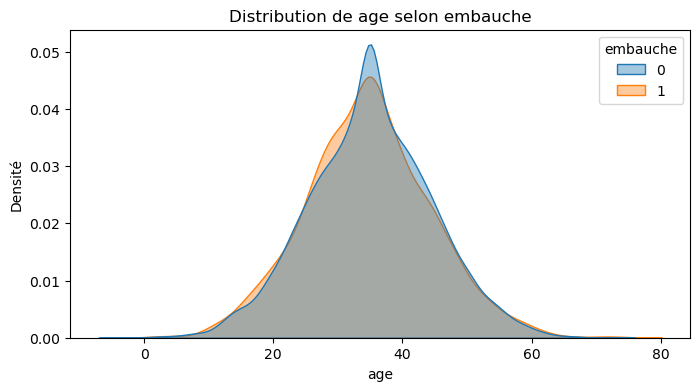

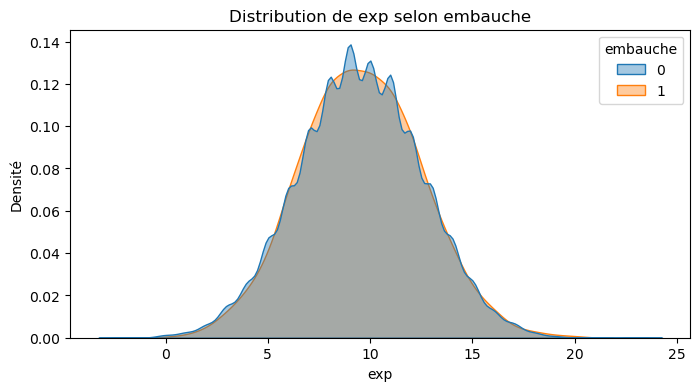

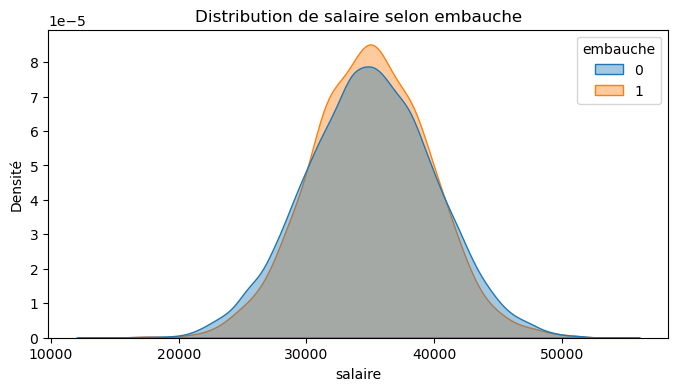

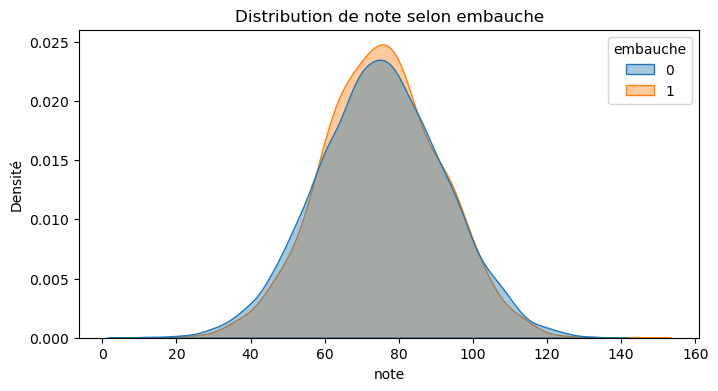

In [ ]:
numeric_vars = ['age', 'exp', 'salaire', 'note']

for v in numeric_vars:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df, x=v, hue='embauche', fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribution de {v} selon embauche")
    plt.xlabel(v)
    plt.ylabel("Densité")
    plt.show()


### DISTRIBUTIONS D'EMBAUCHE par Fréquence

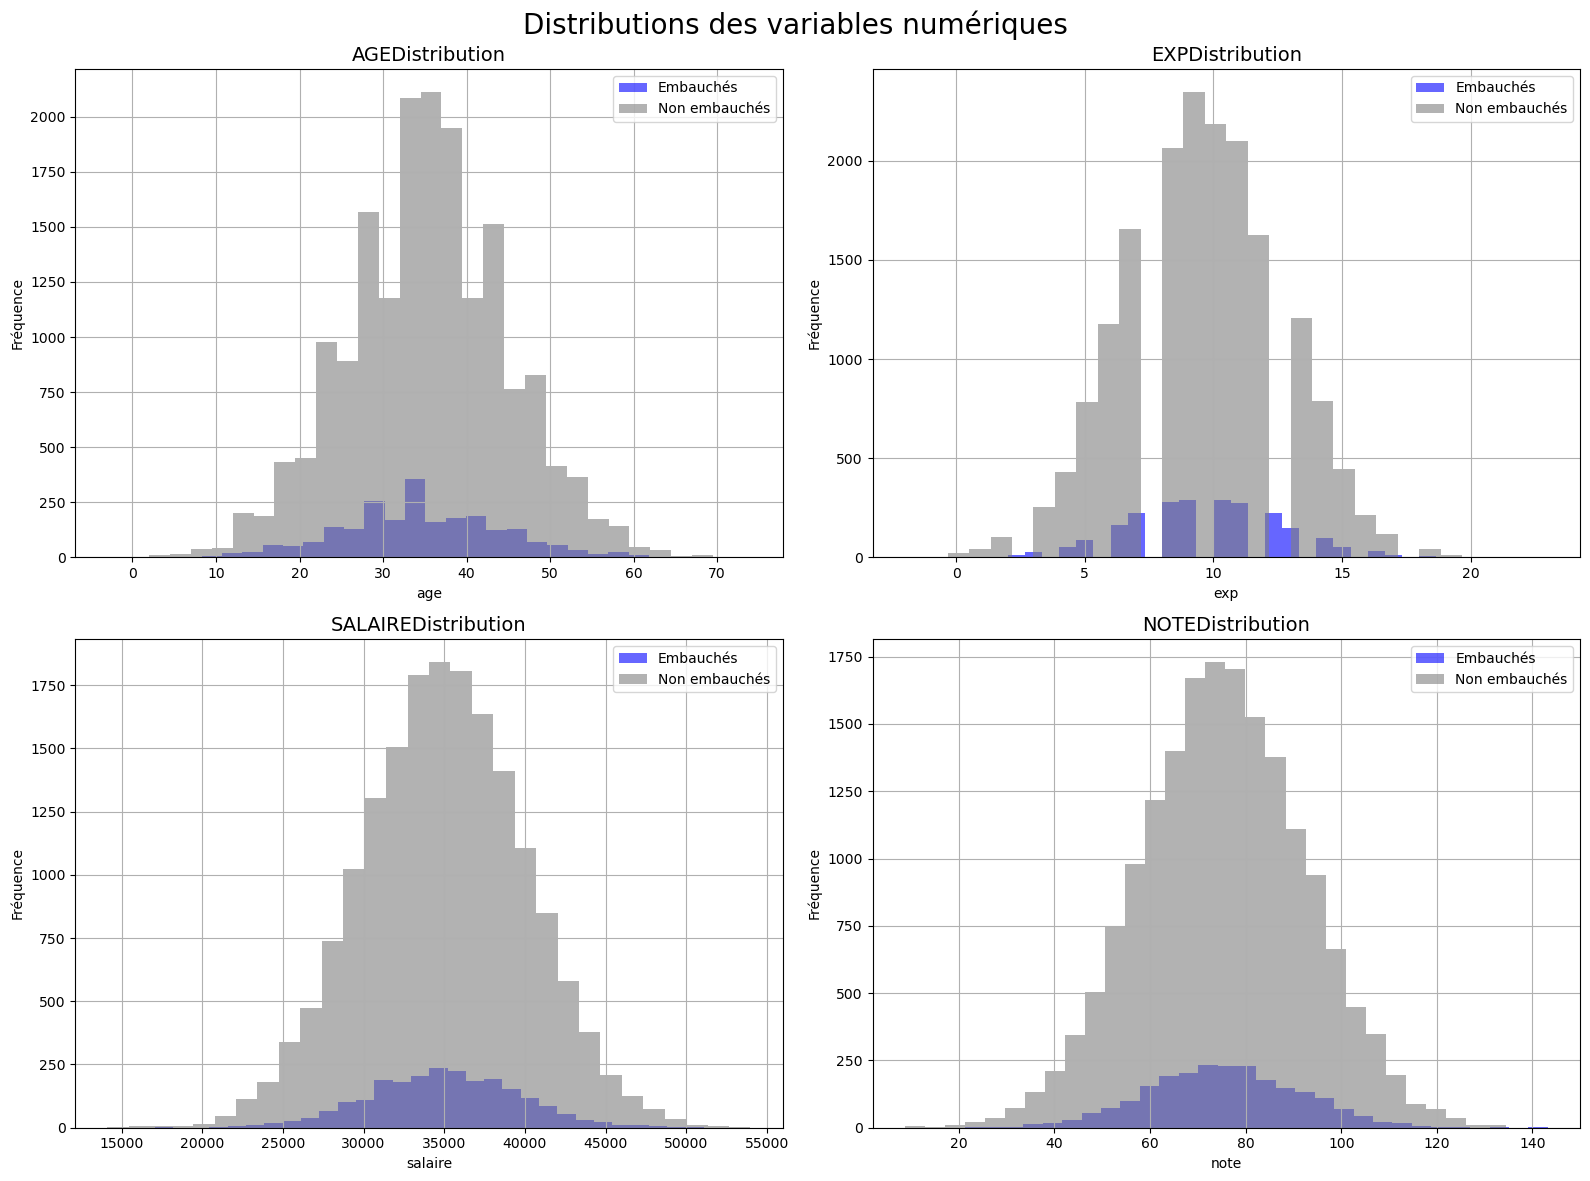

In [ ]:
# Création des graphiques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Distributions des variables numériques", fontsize=20)
# Liste des variables a afficher
variables = ["age", "exp", "salaire", "note"]

for i in range(len(variables)):
    var = variables[i]
    ax = axes[i // 2][i % 2]  

    #les personnes embauchées
    df[df["embauche"] == 1][var].hist(
        bins=30,
        color="blue",
        alpha=0.6,
        ax=ax,
        label="Embauchés"
    )

    #les personnes non embauchées
    df[df["embauche"] == 0][var].hist(
        bins=30,
        color="gray",
        alpha=0.6,
        ax=ax,
        label="Non embauchés"
    )

    # Titres+labels
    ax.set_title(var.upper() + "Distribution", fontsize=14)
    ax.set_xlabel(var)
    ax.set_ylabel("Fréquence")
    ax.legend()
    ax.grid(True)

#affichage
plt.tight_layout()
plt.show()


### Distribution selon un critére en fonction du Nombre de candidats

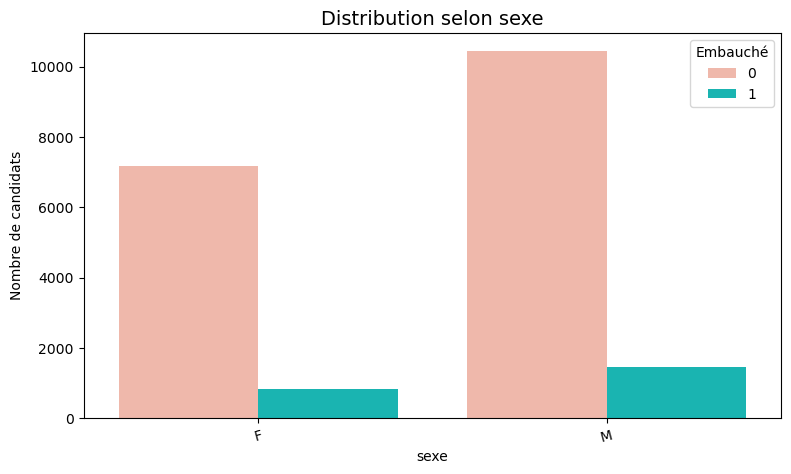

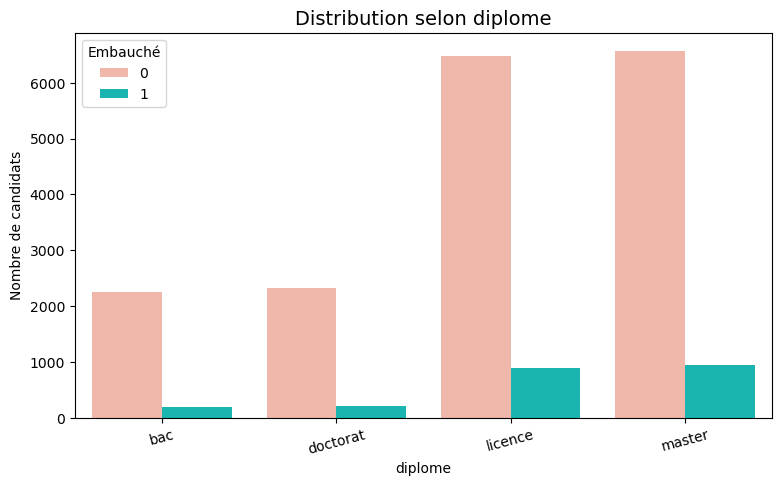

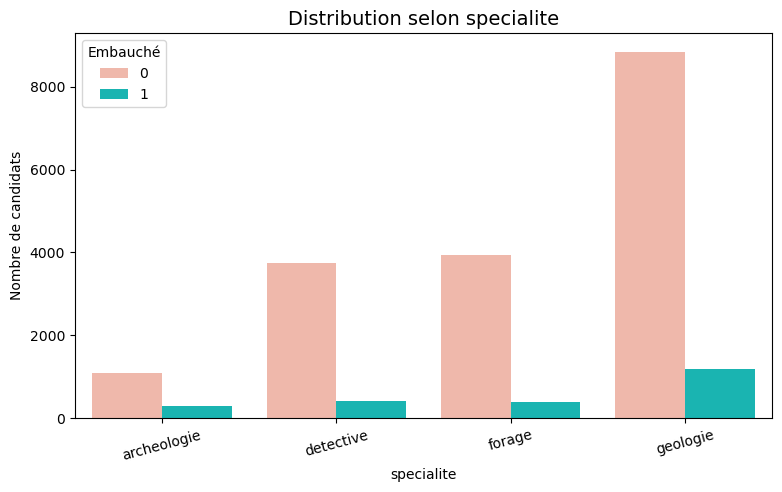

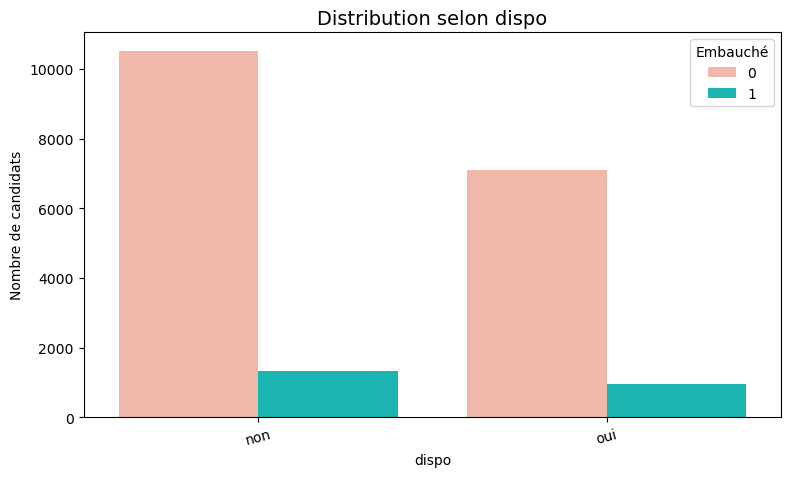

In [ ]:
cat_vars = ["sexe", "diplome", "specialite", "dispo"]

for col in cat_vars:
    plt.figure(figsize=(9,5))
    prop = (
        df.groupby([col, "embauche"])
        .size()
        .reset_index(name="count")
    )

    sns.barplot(data=prop, x=col, y="count", hue="embauche",
                palette=["#fab1a0", "#00cec9"])
    plt.title(f"Distribution selon {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Nombre de candidats")
    plt.legend(title="Embauché")
    plt.xticks(rotation=15)
    plt.show()

### % d’embauches en fonction du critére

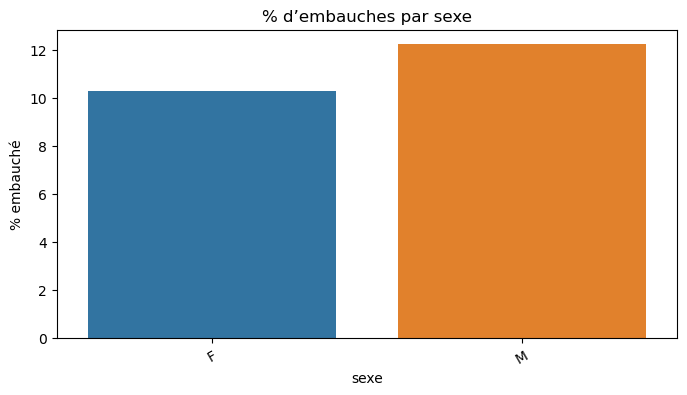

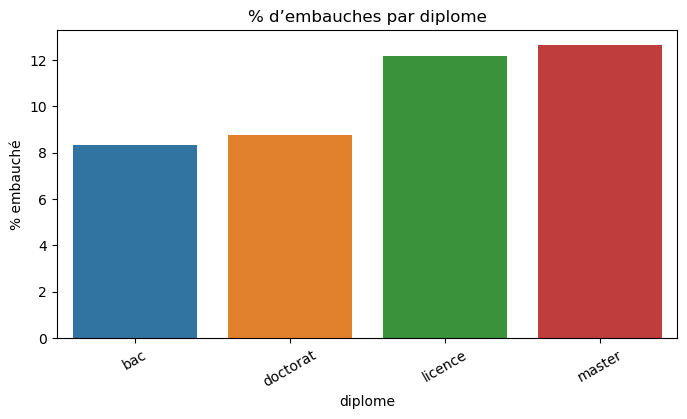

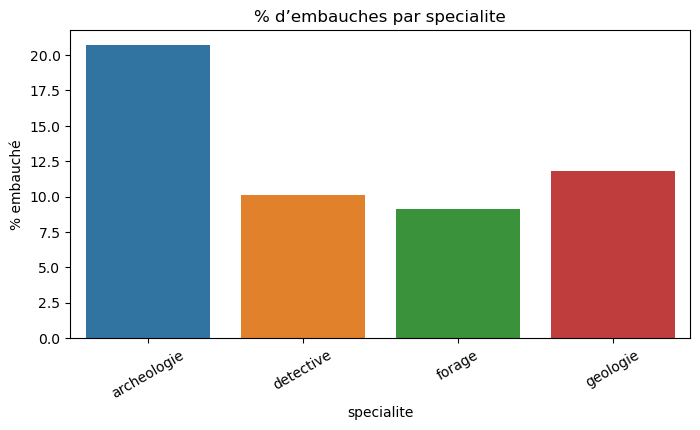

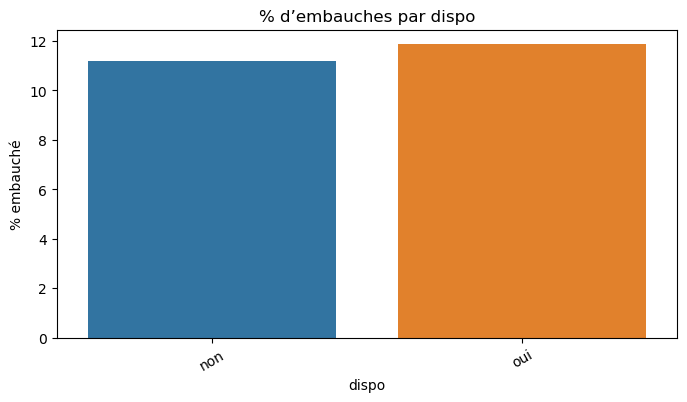

In [ ]:
cat_vars = ['sexe', 'diplome', 'specialite', 'dispo']

for c in cat_vars:
    if c in df:
        plt.figure(figsize=(8,4))
        ct = pd.crosstab(df[c], df['embauche'], normalize='index') * 100
        sns.barplot(x=ct.index, y=ct[1])
        plt.title(f"% d’embauches par {c}")
        plt.ylabel("% embauché")
        plt.xlabel(c)
        plt.xticks(rotation=30)
        plt.show()

### % d’embauches en fonction du critére pour les embauche et non embauche

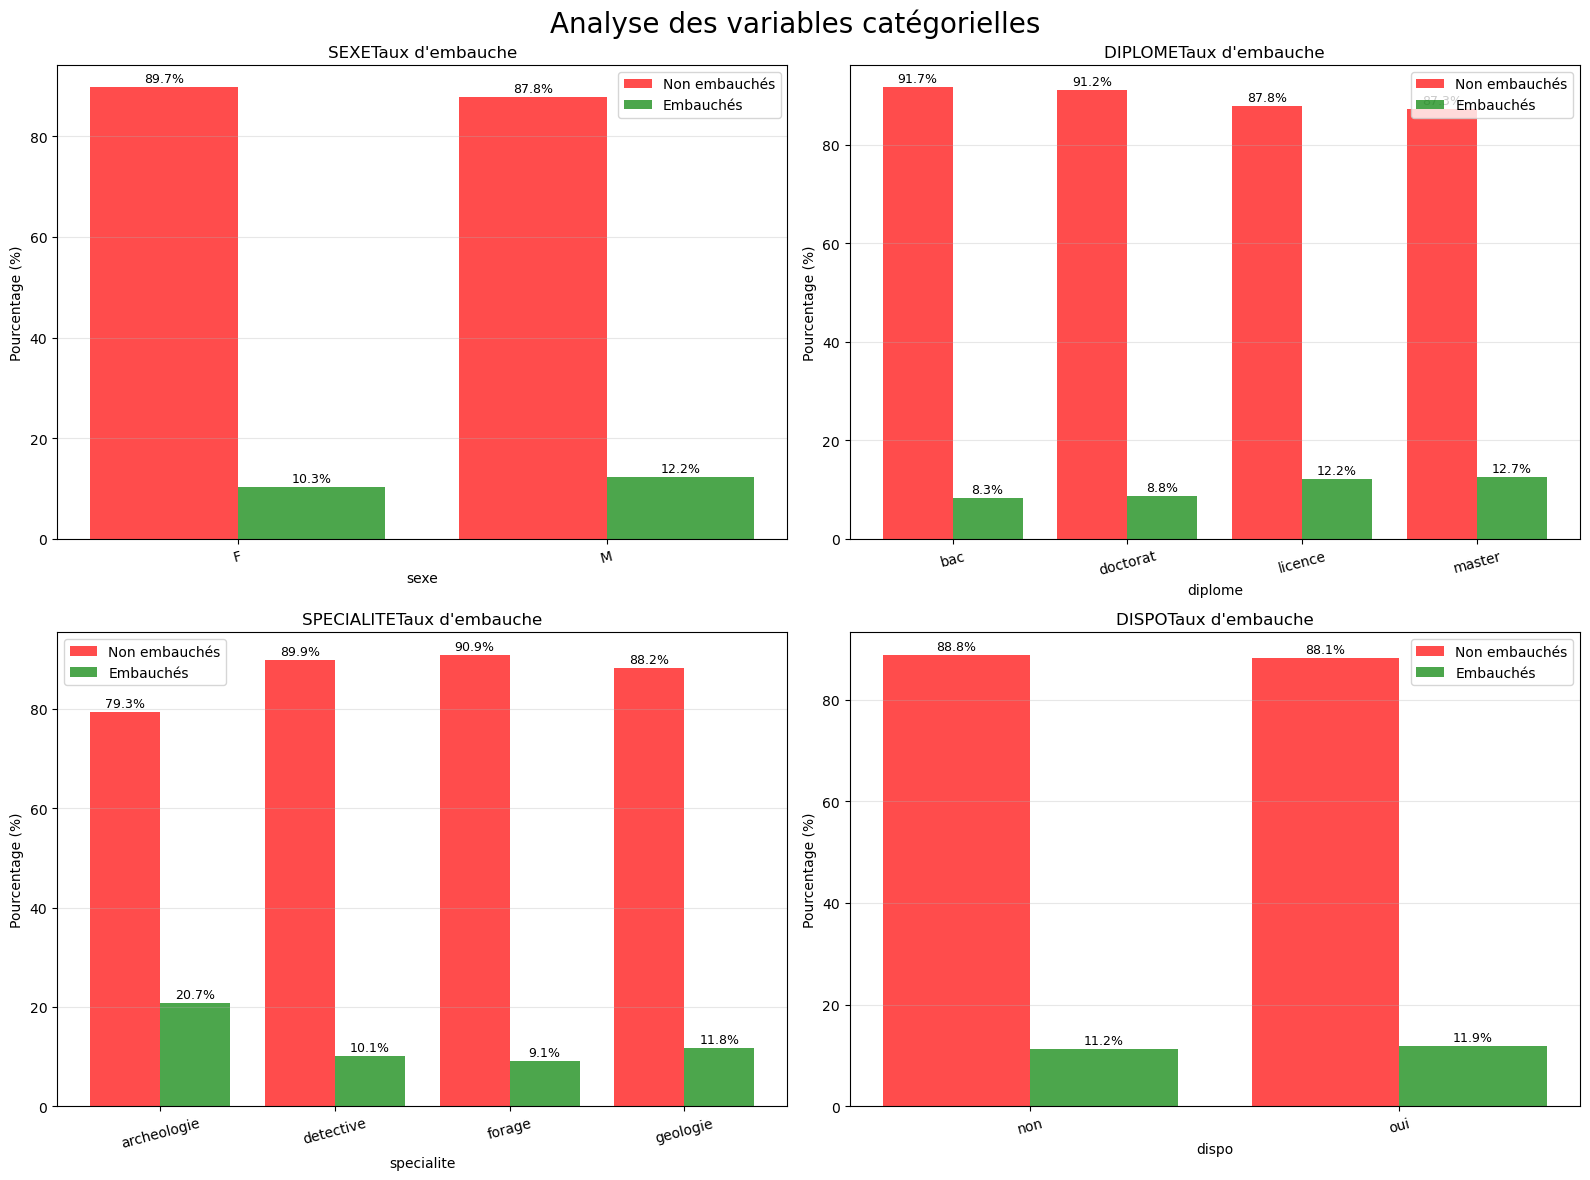

In [ ]:
cat_vars = ['sexe', 'diplome', 'specialite', 'dispo']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Analyse des variables catégorielles", fontsize=20)

for i in range(len(cat_vars)):
    var = cat_vars[i]
    ax = axes[i // 2][i % 2]  

    #le pourcentage d'embauche par catégorie
    tableau = pd.crosstab(df[var], df['embauche'], normalize='index') * 100

    x = np.arange(len(tableau.index))

    # Barres pour non embauchés
    b1 = ax.bar(x - 0.2, tableau[0], width=0.4,
                label="Non embauchés",
                color="red", alpha=0.7)

    # Barres pour embauchés
    b2 = ax.bar(x + 0.2, tableau[1], width=0.4,
                label="Embauchés",
                color="green", alpha=0.7)

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{bar.get_height():.1f}%",
                ha="center", fontsize=9)

    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{bar.get_height():.1f}%",
                ha="center", fontsize=9)

    # Titres et labels
    ax.set_title(var.upper() + "Taux d'embauche")
    ax.set_xlabel(var)
    ax.set_ylabel("Pourcentage (%)")

    ax.set_xticks(x)
    ax.set_xticklabels(tableau.index, rotation=15)

    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


RÉSUMÉ FINAL

In [ ]:
print(" RÉSUMÉ DE L'ANALYSE")
print(f"""
Profil type du candidat EMBAUCHÉ:
  -Âge moyen: {df[df['embauche']==1]['age'].mean():.1f} ans
  -Expérience moyenne: {df[df['embauche']==1]['exp'].mean():.1f} ans
  -Salaire moyen: {df[df['embauche']==1]['salaire'].mean():.0f} €
  -Note moyenne: {df[df['embauche']==1]['note'].mean():.1f}/100
Diplôme le plus embauché: {df[df['embauche']==1]['diplome'].mode()[0]}
Spécialité la plus embauchée: {df[df['embauche']==1]['specialite'].mode()[0]}
""")

 RÉSUMÉ DE L'ANALYSE

Profil type du candidat EMBAUCHÉ:
  -Âge moyen: 34.7 ans
  -Expérience moyenne: 9.6 ans
  -Salaire moyen: 35007 €
  -Note moyenne: 75.3/10
Diplôme le plus embauché: master
Spécialité la plus embauchée: geologie



# 2-Profil général des candidats

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df2 = pd.read_csv('./data/candidats.csv')
df2 = df2.drop(['Unnamed: 0','date','cheveux'], axis = 1)
df2

,age,exp,salaire,sexe,diplome,specialite,note,dispo,embauche
0,25.0,9.0,26803.0,F,licence,geologie,97.08,non,0
1,35.0,13.0,38166.0,M,licence,forage,63.86,non,0
2,29.0,13.0,35207.0,M,licence,geologie,78.50,non,0
3,NaN,12.0,32442.0,M,licence,geologie,45.09,non,0
4,35.0,6.0,28533.0,F,licence,detective,81.91,non,0
...,...,...,...,...,...,...,...,...,...
19995,47.0,9.0,35723.0,M,licence,geologie,66.47,non,0
19996,38.0,10.0,33570.0,F,master,geologie,62.29,non,1
19997,23.0,6.0,33751.0,F,doctorat,detective,103.48,oui,0
19998,33.0,11.0,34167.0,F,licence,detective,73.35,non,0


In [68]:
df2 = df2.dropna(axis = 0)    # on retire les lignes où il manque des données (représenté par NaN)
df2

,age,exp,salaire,sexe,diplome,specialite,note,dispo,embauche
0,25.0,9.0,26803.0,F,licence,geologie,97.08,non,0
1,35.0,13.0,38166.0,M,licence,forage,63.86,non,0
2,29.0,13.0,35207.0,M,licence,geologie,78.50,non,0
4,35.0,6.0,28533.0,F,licence,detective,81.91,non,0
5,37.0,8.0,38558.0,M,master,geologie,63.46,non,1
...,...,...,...,...,...,...,...,...,...
19995,47.0,9.0,35723.0,M,licence,geologie,66.47,non,0
19996,38.0,10.0,33570.0,F,master,geologie,62.29,non,1
19997,23.0,6.0,33751.0,F,doctorat,detective,103.48,oui,0
19998,33.0,11.0,34167.0,F,licence,detective,73.35,non,0


## Statistiques descriptives selon différents paramètres


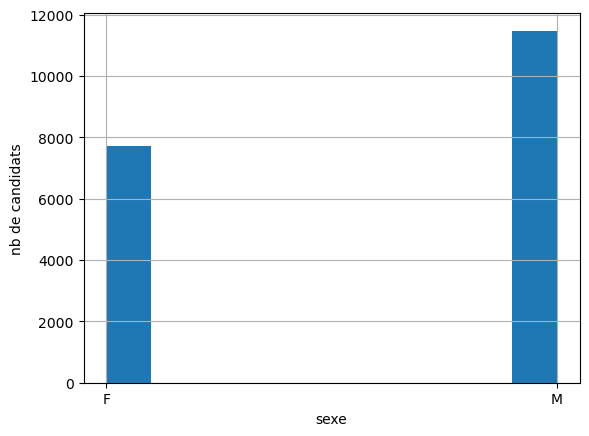

In [69]:
# stat. descriptives selon le sexe

plt.figure()

df2['sexe'].hist()
plt.xlabel('sexe')
plt.ylabel('nb de candidats')
plt.title

plt.show()


           salaire
sexe              
F     34172.348246
M     35501.566210


sexe
F    [[Axes(0.125,0.11;0.775x0.77)]]
M    [[Axes(0.125,0.11;0.775x0.77)]]
Name: (salaire,), dtype: object

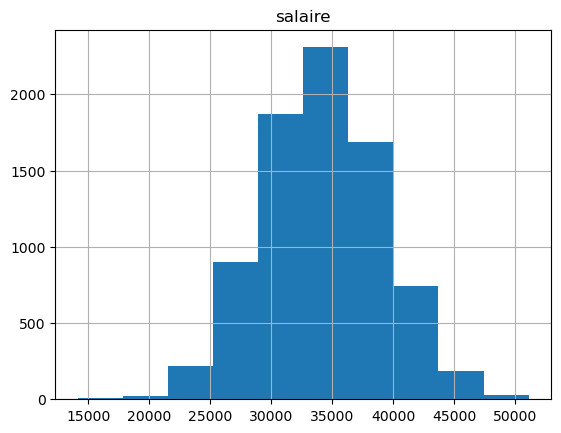

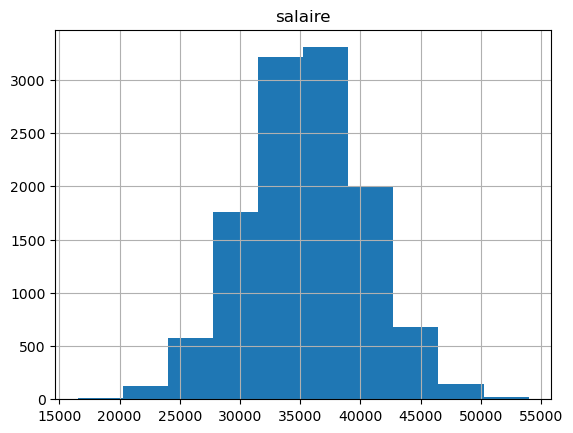

In [113]:
wage = df.groupby(['sexe'])[['salaire']]
print(wage.mean())
wage.hist()

In [ ]:
degree = df.groupby(['sexe'])[['diplome']]
degree.value_counts()

sexe  diplome 
F     master      3090
      licence     2833
      doctorat    1181
      bac          865
M     licence     4505
      master      4392
      bac         1569
      doctorat    1355
Name: count, dtype: int64

In [120]:
spe = df.groupby(['sexe'])[['specialite']]
spe.value_counts()

sexe  specialite 
F     detective      2522
      geologie       2403
      forage         1964
      archeologie    1081
M     geologie       7576
      forage         2351
      detective      1614
      archeologie     298
Name: count, dtype: int64